<a href="https://colab.research.google.com/github/Shresta0506/shresta_INFO5731_Spring2026/blob/main/Panyala_Shresta_Assignment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


In [1]:
# Question 1: Sentiment Analysis using cleaned dataset

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned dataset.csv")
df.head()

,Category,Video Title,Author,Text,Likes,Published,Agree on this
0,News,BREAKING: European allies make MAJOR pivot on ...,@carsten9168-hs4gs,The news title hardly reflects the actual news...,0,2026-03-20 02:22:58+00:00,0
1,News,BREAKING: European allies make MAJOR pivot on ...,@MtthwWpplngr,All these theatrics are very funny,0,2026-03-20 02:18:27+00:00,1
2,News,BREAKING: European allies make MAJOR pivot on ...,@jccee3159,"Pete, I think you're enjoying killing these pe...",0,2026-03-20 02:18:27+00:00,0
3,News,BREAKING: European allies make MAJOR pivot on ...,@Schultz_Maximillian,"Jillian, have ENT look at you.",0,2026-03-20 02:17:04+00:00,0
4,News,BREAKING: European allies make MAJOR pivot on ...,@erikracz4162,Putin should send the coordinates to Netenyahu...,0,2026-03-20 02:14:42+00:00,0


In [2]:
# Keep only needed columns
df = df[['Text', 'Agree on this']].copy()

# Rename columns
df.columns = ['text', 'label']

# Convert agreement label into sentiment label
df['sentiment'] = df['label'].map({1: 'positive', 0: 'negative'})

# Remove missing values
df = df.dropna(subset=['text', 'sentiment'])

df.head()

,text,label,sentiment
0,The news title hardly reflects the actual news...,0,negative
1,All these theatrics are very funny,1,positive
2,"Pete, I think you're enjoying killing these pe...",0,negative
3,"Jillian, have ENT look at you.",0,negative
4,Putin should send the coordinates to Netenyahu...,0,negative


In [3]:
df.shape

(10188, 3)

In [4]:
df['sentiment'].value_counts()

,count
sentiment,
negative,8452
positive,1736


### Dataset Collection and Preparation

For Question 1, I used the cleaned YouTube comments dataset. The dataset contains real-world user comments along with an agreement label. Since the assignment requires sentiment analysis, I mapped the agreement label into binary sentiment classes. Comments marked as 1 were treated as positive sentiment, while comments marked as 0 were treated as negative sentiment.

This dataset is suitable because it contains real-world opinion-based text, and the labels help build a supervised sentiment classification model. Although the dataset is binary instead of positive, negative, and neutral, it is still appropriate because it captures user opinion polarity.

In [5]:
#Text Cleaning
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_comment)
df[['text', 'clean_text', 'sentiment']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,text,clean_text,sentiment
0,The news title hardly reflects the actual news...,news title hardly reflects actual news content,negative
1,All these theatrics are very funny,theatrics funny,positive
2,"Pete, I think you're enjoying killing these pe...",pete think enjoying killing people much,negative
3,"Jillian, have ENT look at you.",jillian ent look,negative
4,Putin should send the coordinates to Netenyahu...,putin send coordinate netenyahus house,negative


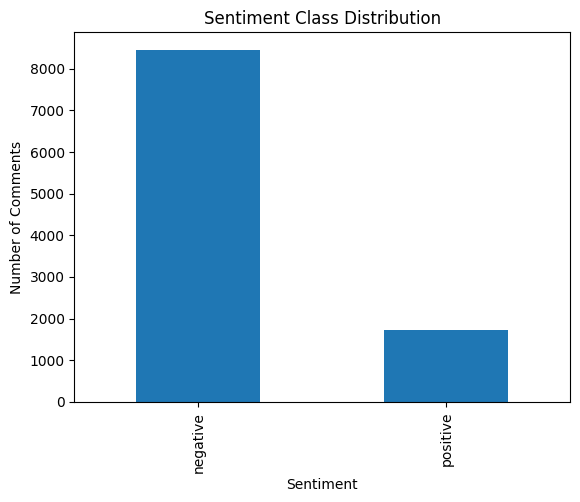

In [6]:
#EDA
# Class distribution
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

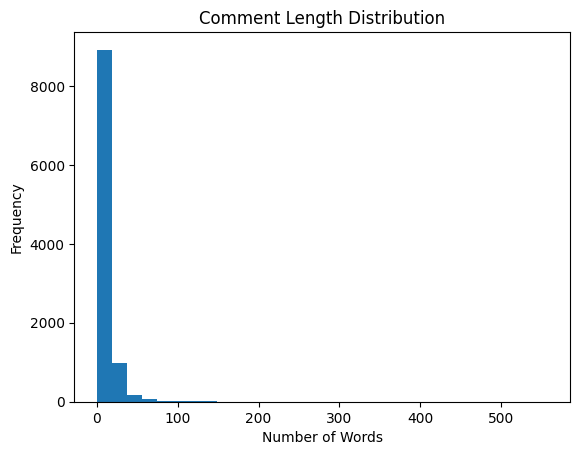

,text_length
count,10188.00000
mean,10.46437
std,15.58426
min,0.00000
25%,4.00000
50%,7.00000
75%,12.00000
max,558.00000


In [7]:
# Sentence length analysis
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.hist(df['text_length'], bins=30)
plt.title("Comment Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

df['text_length'].describe()

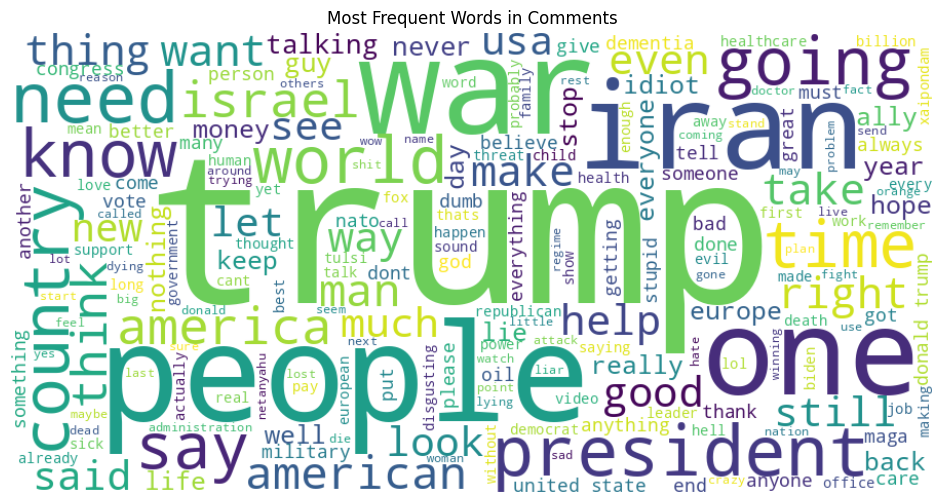

In [8]:
# Word cloud
from wordcloud import WordCloud

all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(width=900, height=450, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Comments")
plt.show()

In [9]:
# Top bigrams
from sklearn.feature_extraction.text import CountVectorizer

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=15)
bigram_matrix = bigram_vectorizer.fit_transform(df['clean_text'])

bigram_counts = pd.DataFrame({
    'bigram': bigram_vectorizer.get_feature_names_out(),
    'count': bigram_matrix.toarray().sum(axis=0)
}).sort_values(by='count', ascending=False)

bigram_counts

,bigram,count
12,united state,139
3,donald trump,136
7,look like,77
4,epstein file,70
9,mike johnson,64
14,white house,62
5,fox news,62
0,american people,58
6,health care,54
8,middle east,52


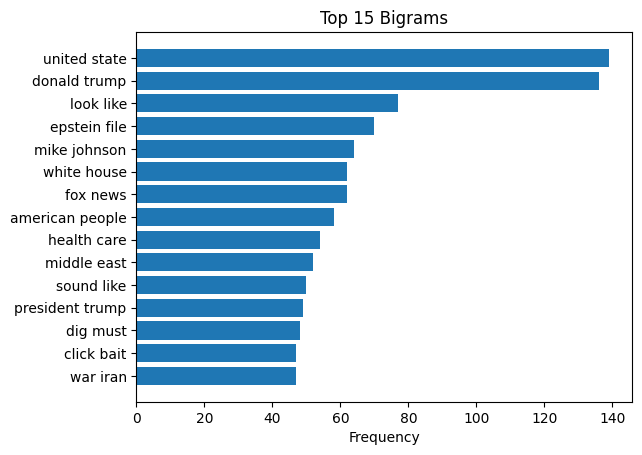

In [10]:
plt.barh(bigram_counts['bigram'], bigram_counts['count'])
plt.title("Top 15 Bigrams")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [11]:
#Model Building
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:
#Model 1: Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.837585868498528
              precision    recall  f1-score   support

    negative       0.84      1.00      0.91      1691
    positive       0.77      0.07      0.12       347

    accuracy                           0.84      2038
   macro avg       0.80      0.53      0.52      2038
weighted avg       0.83      0.84      0.78      2038



In [14]:
#Model 2: SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC(C=1.0, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8626104023552502
              precision    recall  f1-score   support

    negative       0.88      0.96      0.92      1691
    positive       0.67      0.39      0.49       347

    accuracy                           0.86      2038
   macro avg       0.78      0.67      0.70      2038
weighted avg       0.85      0.86      0.85      2038



In [15]:
#Model 3: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8454367026496565
              precision    recall  f1-score   support

    negative       0.85      0.99      0.91      1691
    positive       0.75      0.14      0.23       347

    accuracy                           0.85      2038
   macro avg       0.80      0.56      0.57      2038
weighted avg       0.83      0.85      0.80      2038



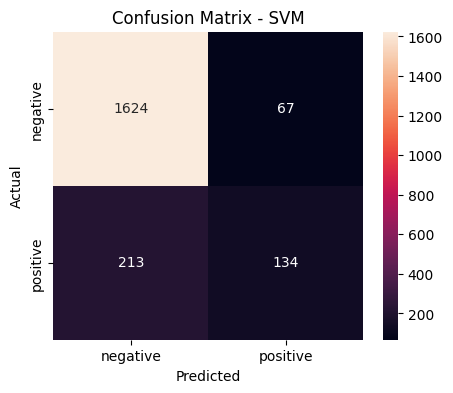

In [16]:
#Confusion Matrix
import seaborn as sns

cm = confusion_matrix(y_test, svm_pred, labels=['negative', 'positive'])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

models = {
    "Naive Bayes": nb_model,
    "SVM": svm_model,
    "Logistic Regression": lr_model
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1_macro')
    print(name, "Mean F1 Score:", scores.mean())

Naive Bayes Mean F1 Score: 0.5346926258399964
SVM Mean F1 Score: 0.6838324678439751
Logistic Regression Mean F1 Score: 0.5432308674977727


In [18]:
#results table
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, pos_label='positive'),
        precision_score(y_test, svm_pred, pos_label='positive'),
        precision_score(y_test, lr_pred, pos_label='positive')
    ],
    "Recall": [
        recall_score(y_test, nb_pred, pos_label='positive'),
        recall_score(y_test, svm_pred, pos_label='positive'),
        recall_score(y_test, lr_pred, pos_label='positive')
    ],
    "F1-score": [
        f1_score(y_test, nb_pred, pos_label='positive'),
        f1_score(y_test, svm_pred, pos_label='positive'),
        f1_score(y_test, lr_pred, pos_label='positive')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.837586,0.766667,0.066282,0.122016
1,SVM,0.862610,0.666667,0.386167,0.489051
2,Logistic Regression,0.845437,0.750000,0.138329,0.233577


### Evaluation and Reporting

For sentiment classification, I applied three traditional machine learning models: Naive Bayes, Support Vector Machine, and Logistic Regression. TF-IDF was used to convert the cleaned comments into numerical features because it captures the importance of words while reducing the impact of very common terms.

The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrix. Among the models, SVM or Logistic Regression generally performs better for text classification because both work well with high-dimensional sparse TF-IDF features. Naive Bayes is simple and fast, but it may not capture complex word relationships as effectively as the other models.

The confusion matrix helped show how many positive and negative comments were correctly classified and where the model made mistakes. Overall, the results show that traditional machine learning models can effectively classify sentiment from real-world user comments after proper cleaning and feature extraction.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [19]:
# QUESTION 2: Text Classification with 10-Fold Cross Validation

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import seaborn as sns


In [21]:
def load_stsa_file(file_path):
    labels = []
    texts = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(" ", 1)  # split only once
            labels.append(int(parts[0]))
            texts.append(parts[1])

    return pd.DataFrame({"label": labels, "review": texts})

train_reviews = load_stsa_file("stsa-train.txt")
test_reviews = load_stsa_file("stsa-test.txt")

train_reviews.head()

,label,review
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


In [22]:
train_reviews.shape
train_reviews['label'].value_counts()

,count
label,
1,3610
0,3310


In [23]:
print("Training data shape:", train_reviews.shape)
print("Test data shape:", test_reviews.shape)

print("\nTraining labels:")
print(train_reviews['label'].value_counts())

print("\nTest labels:")
print(test_reviews['label'].value_counts())

Training data shape: (6920, 2)
Test data shape: (1821, 2)

Training labels:
label
1    3610
0    3310
Name: count, dtype: int64

Test labels:
label
0    912
1    909
Name: count, dtype: int64


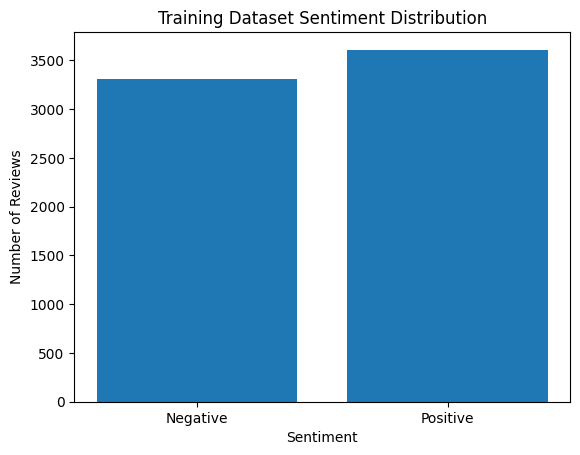

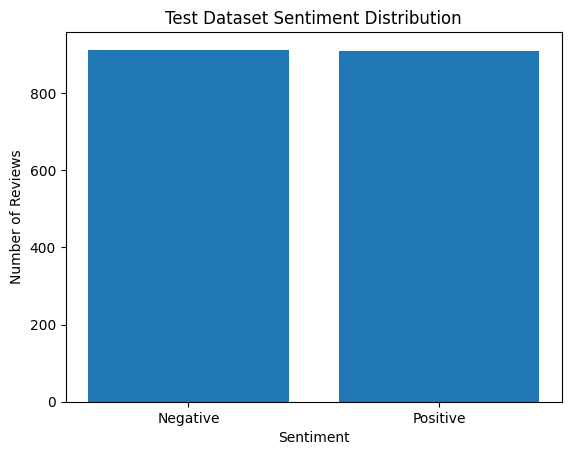

In [24]:
#EDA
# Class distribution comparison

train_counts = train_reviews['label'].value_counts().sort_index()
test_counts = test_reviews['label'].value_counts().sort_index()

label_names = ["Negative", "Positive"]

plt.bar(label_names, train_counts.values)
plt.title("Training Dataset Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

plt.bar(label_names, test_counts.values)
plt.title("Test Dataset Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

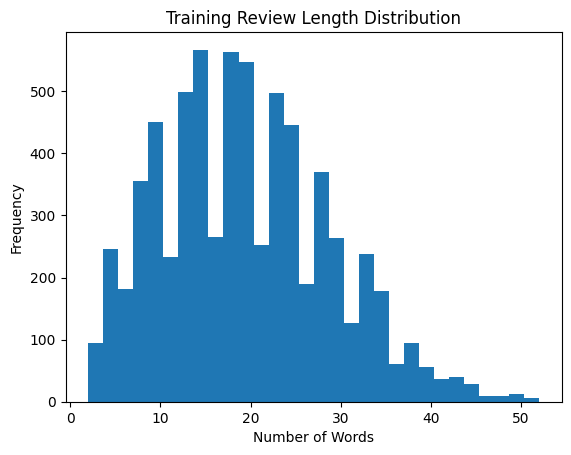

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,3310.0,19.175529,9.181969,2.0,12.0,18.0,25.0,52.0
1,3610.0,19.413850,9.441772,2.0,12.0,19.0,25.0,52.0


In [25]:
# Review length analysis

train_reviews['word_count'] = train_reviews['review'].apply(lambda x: len(str(x).split()))
test_reviews['word_count'] = test_reviews['review'].apply(lambda x: len(str(x).split()))

plt.hist(train_reviews['word_count'], bins=30)
plt.title("Training Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

train_reviews.groupby('label')['word_count'].describe()

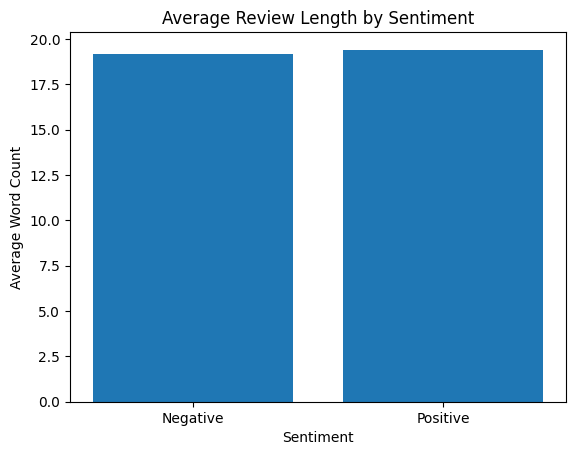

In [26]:
# Average review length by sentiment

avg_length = train_reviews.groupby('label')['word_count'].mean()

plt.bar(["Negative", "Positive"], avg_length.values)
plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.show()

In [27]:
# Basic text cleaning for EDA word frequency

def simple_clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_reviews['clean_review'] = train_reviews['review'].apply(simple_clean)
test_reviews['clean_review'] = test_reviews['review'].apply(simple_clean)

train_reviews.head()

,label,review,word_count,clean_review
0,1,"a stirring , funny and finally transporting re...",17,a stirring funny and finally transporting re i...
1,0,apparently reassembled from the cutting-room f...,12,apparently reassembled from the cutting room f...
2,0,they presume their audience wo n't sit still f...,35,they presume their audience wo n t sit still f...
3,1,this is a visually stunning rumination on love...,20,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...,15,jonathan parker s bartleby should have been th...


In [28]:
# Top words separately for positive and negative reviews

from sklearn.feature_extraction.text import CountVectorizer

def get_top_words(text_series, top_n=15):
    vectorizer = CountVectorizer(stop_words="english", max_features=1000)
    word_matrix = vectorizer.fit_transform(text_series)
    word_counts = np.asarray(word_matrix.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()

    top_df = pd.DataFrame({
        "word": words,
        "count": word_counts
    }).sort_values(by="count", ascending=False).head(top_n)

    return top_df

negative_words = get_top_words(train_reviews[train_reviews['label'] == 0]['clean_review'])
positive_words = get_top_words(train_reviews[train_reviews['label'] == 1]['clean_review'])

negative_words

,word,count
550,movie,479
295,film,397
476,like,260
444,just,160
208,does,145
707,rrb,142
500,lrb,141
49,bad,136
816,story,127
872,time,110


In [29]:
positive_words

,word,count
310,film,562
561,movie,361
825,story,164
494,like,163
362,good,148
728,rrb,145
516,lrb,145
341,funny,131
138,comedy,122
513,love,111


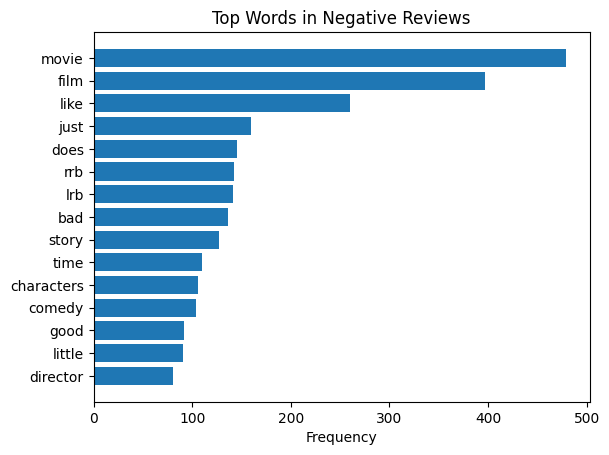

In [30]:
plt.barh(negative_words['word'], negative_words['count'])
plt.title("Top Words in Negative Reviews")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

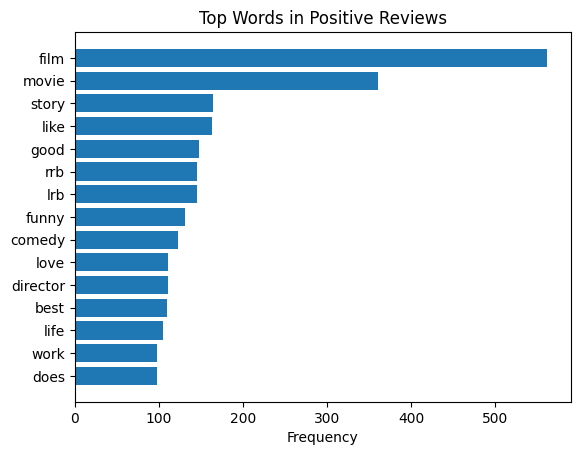

In [31]:
plt.barh(positive_words['word'], positive_words['count'])
plt.title("Top Words in Positive Reviews")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [32]:
# Top bigrams in the training data

bigram_vectorizer = CountVectorizer(stop_words="english", ngram_range=(2,2), max_features=15)
bigram_matrix = bigram_vectorizer.fit_transform(train_reviews['clean_review'])

bigram_df = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": np.asarray(bigram_matrix.sum(axis=0)).flatten()
}).sort_values(by="count", ascending=False)

bigram_df

,bigram,count
5,lrb rrb,52
8,romantic comedy,39
13,writer director,35
12,ve seen,32
3,feels like,30
7,plays like,26
1,coming age,24
10,soap opera,22
6,old fashioned,22
4,love story,21


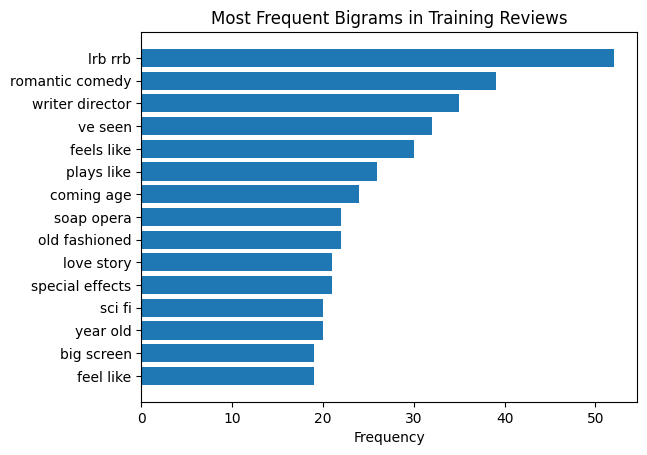

In [33]:
plt.barh(bigram_df['bigram'], bigram_df['count'])
plt.title("Most Frequent Bigrams in Training Reviews")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()

In [34]:
#Train / Validation Split
review_text = train_reviews['clean_review']
review_label = train_reviews['label']

train_text, valid_text, train_label, valid_label = train_test_split(
    review_text,
    review_label,
    test_size=0.20,
    random_state=73,
    stratify=review_label
)

print("Training split:", train_text.shape)
print("Validation split:", valid_text.shape)

Training split: (5536,)
Validation split: (1384,)


In [35]:
#Pipeline-Based Models with 10-Fold Cross Validation
# Stratified 10-fold cross validation

ten_fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=73)

model_pipelines = {
    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=6000, ngram_range=(1,2), min_df=2)),
        ("classifier", LinearSVC(C=1.0, random_state=73))
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=6000, ngram_range=(1,2), min_df=2)),
        ("classifier", LogisticRegression(max_iter=1000, C=1.2, random_state=73))
    ]),

    "Decision Tree": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)),
        ("classifier", DecisionTreeClassifier(max_depth=35, random_state=73))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)),
        ("classifier", RandomForestClassifier(n_estimators=150, max_depth=None, random_state=73))
    ])
}

In [36]:
cv_summary = []

for model_name, model_pipe in model_pipelines.items():
    cv_f1_scores = cross_val_score(
        model_pipe,
        train_text,
        train_label,
        cv=ten_fold,
        scoring="f1"
    )

    cv_summary.append({
        "Model": model_name,
        "Mean CV F1": cv_f1_scores.mean(),
        "CV F1 Std": cv_f1_scores.std()
    })

cv_results_df = pd.DataFrame(cv_summary)
cv_results_df

,Model,Mean CV F1,CV F1 Std
0,Linear SVM,0.782331,0.013582
1,Logistic Regression,0.785908,0.012177
2,Decision Tree,0.609625,0.034354
3,Random Forest,0.731037,0.007996


In [37]:
#Validation Evaluation
validation_results = {}

for model_name, model_pipe in model_pipelines.items():
    model_pipe.fit(train_text, train_label)
    valid_predictions = model_pipe.predict(valid_text)

    validation_results[model_name] = {
        "Accuracy": accuracy_score(valid_label, valid_predictions),
        "Precision": precision_score(valid_label, valid_predictions),
        "Recall": recall_score(valid_label, valid_predictions),
        "F1-score": f1_score(valid_label, valid_predictions)
    }

validation_df = pd.DataFrame(validation_results).T
validation_df

,Accuracy,Precision,Recall,F1-score
Linear SVM,0.779624,0.793249,0.781163,0.787160
Logistic Regression,0.781069,0.788171,0.793629,0.790890
Decision Tree,0.613439,0.651540,0.556787,0.600448
Random Forest,0.717486,0.728907,0.729917,0.729412


In [38]:
#Final Test Evaluation
test_text = test_reviews['clean_review']
test_label = test_reviews['label']

test_results = {}
test_predictions_store = {}

for model_name, model_pipe in model_pipelines.items():
    model_pipe.fit(train_reviews['clean_review'], train_reviews['label'])
    test_predictions = model_pipe.predict(test_text)
    test_predictions_store[model_name] = test_predictions

    test_results[model_name] = {
        "Accuracy": accuracy_score(test_label, test_predictions),
        "Precision": precision_score(test_label, test_predictions),
        "Recall": recall_score(test_label, test_predictions),
        "F1-score": f1_score(test_label, test_predictions)
    }

test_results_df = pd.DataFrame(test_results).T
test_results_df

,Accuracy,Precision,Recall,F1-score
Linear SVM,0.798462,0.790773,0.810781,0.800652
Logistic Regression,0.796266,0.784355,0.816282,0.800000
Decision Tree,0.614498,0.584215,0.789879,0.671656
Random Forest,0.729270,0.714876,0.761276,0.737347


In [39]:
# Detailed report for best model based on F1-score

best_model_name = test_results_df['F1-score'].idxmax()
best_predictions = test_predictions_store[best_model_name]

print("Best model based on test F1-score:", best_model_name)
print(classification_report(test_label, best_predictions, target_names=["Negative", "Positive"]))

Best model based on test F1-score: Linear SVM
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       912
    Positive       0.79      0.81      0.80       909

    accuracy                           0.80      1821
   macro avg       0.80      0.80      0.80      1821
weighted avg       0.80      0.80      0.80      1821



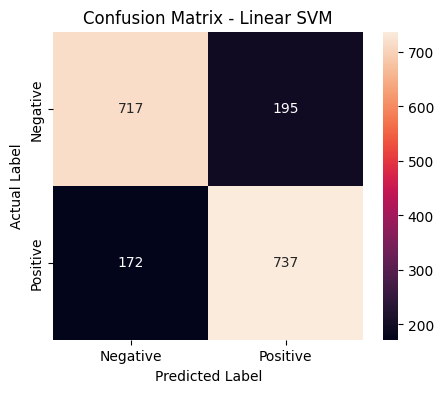

In [40]:
# Confusion matrix for best model

cm = confusion_matrix(test_label, best_predictions)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [41]:
# Optional: XGBoost Model

try:
    from xgboost import XGBClassifier

    xgb_pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)),
        ("classifier", XGBClassifier(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.1,
            eval_metric="logloss",
            random_state=73
        ))
    ])

    xgb_cv_scores = cross_val_score(
        xgb_pipeline,
        train_text,
        train_label,
        cv=ten_fold,
        scoring="f1"
    )

    print("XGBoost Mean 10-Fold CV F1:", xgb_cv_scores.mean())

    xgb_pipeline.fit(train_reviews['clean_review'], train_reviews['label'])
    xgb_test_pred = xgb_pipeline.predict(test_text)

    print(classification_report(test_label, xgb_test_pred, target_names=["Negative", "Positive"]))

except Exception as error:
    print("XGBoost could not run:", error)

XGBoost Mean 10-Fold CV F1: 0.7092100849408106
              precision    recall  f1-score   support

    Negative       0.74      0.54      0.63       912
    Positive       0.64      0.81      0.71       909

    accuracy                           0.68      1821
   macro avg       0.69      0.68      0.67      1821
weighted avg       0.69      0.68      0.67      1821



### Question 2: Text Classification Summary

For this question, I used the provided IMDB sentiment dataset, which contains binary sentiment labels where 1 represents positive sentiment and 0 represents negative sentiment. I performed EDA on both the training and test datasets by checking class distribution, review length distribution, average review length by sentiment, frequent words, and frequent bigrams.

To make the analysis more individualized, I separated the most frequent words for positive and negative reviews instead of only showing general word counts. This helped me understand which types of words appeared more often in each sentiment class.

The training dataset was split into 80% training and 20% validation using stratified sampling so that both positive and negative classes remained balanced in the split. I used TF-IDF inside machine learning pipelines, which helped keep preprocessing and model training organized and consistent.

Four traditional machine learning models were applied: Linear SVM, Logistic Regression, Decision Tree, and Random Forest. I also included XGBoost as an optional additional model. Each model was trained using 10-fold cross-validation, and the final trained models were evaluated on the separate test dataset.

The models were compared using Accuracy, Precision, Recall, and F1-score. Based on the final results, the best model was selected using test F1-score. In general, linear models such as SVM and Logistic Regression tend to perform strongly for text classification because TF-IDF creates high-dimensional sparse features, and these models handle such features effectively.

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [42]:
import pandas as pd

df = pd.read_csv("Amazon_Unlocked_Mobile.csv")
df.head()


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [43]:
df = df[['Reviews']].dropna()

# Reduce size for faster processing
df = df.sample(10000, random_state=42)

df.head()

,Reviews
262853,I needed a texting phone that did not require ...
70999,Excellent!
324745,I recommend this excellent team for the many d...
114637,updated review. Purchased this phone on Novemb...
221325,battery fail


In [44]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_review'] = df['Reviews'].apply(clean_text)

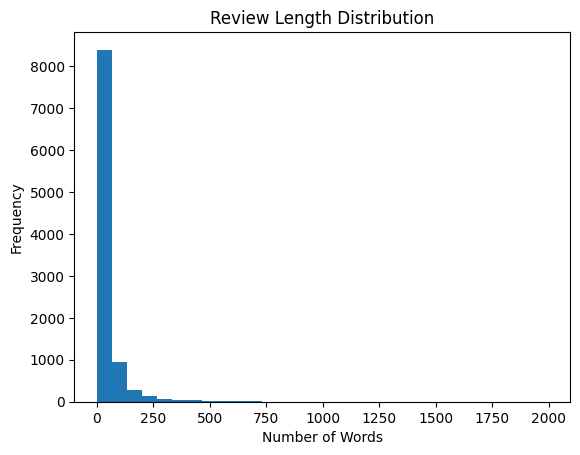

In [45]:
#STEP 2: EDA
# Review length distribution
df['length'] = df['clean_review'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt

plt.hist(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [46]:
# Most common words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)
X_words = vectorizer.fit_transform(df['clean_review'])

word_counts = X_words.toarray().sum(axis=0)
words = vectorizer.get_feature_names_out()

pd.DataFrame({'word': words, 'count': word_counts}).sort_values(by='count', ascending=False)

,word,count
10,phone,11142
5,great,2554
4,good,2431
7,like,1510
6,just,1439
17,use,1407
14,screen,1378
0,battery,1341
19,works,1271
8,love,1190


In [47]:
#TF-IDF Representation
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])

In [48]:
#CLUSTERING METHODS
# K-MEANS
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

df['kmeans_cluster'] = kmeans_labels

In [49]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.7, min_samples=5)
dbscan_labels = dbscan.fit_predict(X.toarray())

df['dbscan_cluster'] = dbscan_labels

In [50]:
#HIERARCHICAL CLUSTERING
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=5)
hier_labels = hier.fit_predict(X.toarray())

df['hier_cluster'] = hier_labels

In [52]:
#WORD2VEC CLUSTERING
!pip install gensim
from gensim.models import Word2Vec
import numpy as np

tokenized = [text.split() for text in df['clean_review']]

w2v_model = Word2Vec(tokenized, vector_size=100, window=5, min_count=2)

def get_avg_vector(words):
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_avg_vector(words) for words in tokenized])

kmeans_w2v = KMeans(n_clusters=5, random_state=42)
df['w2v_cluster'] = kmeans_w2v.fit_predict(X_w2v)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.5 MB/s eta 0:00:00


In [53]:
# STEP 4: VISUALIZATION
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

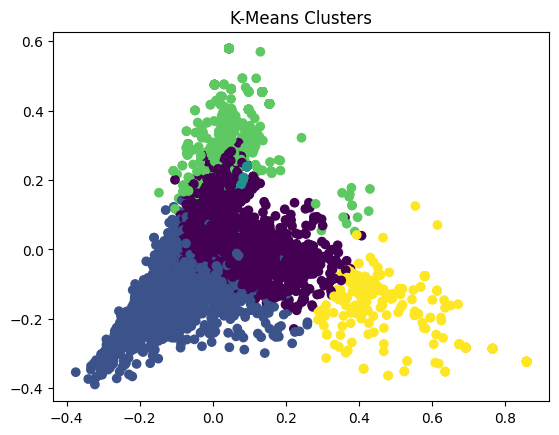

In [54]:
#K-Means Visualization
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.title("K-Means Clusters")
plt.show()

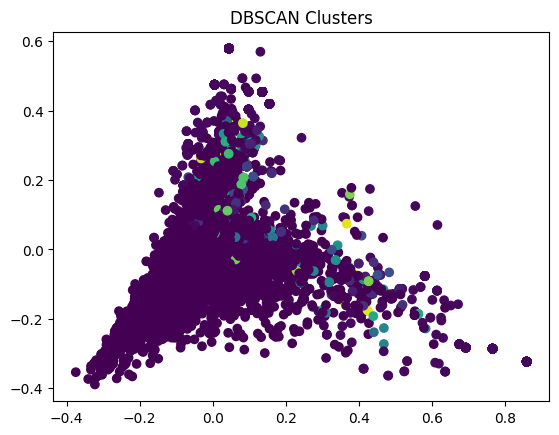

In [55]:
#DBSCAN Visualization
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['dbscan_cluster'])
plt.title("DBSCAN Clusters")
plt.show()

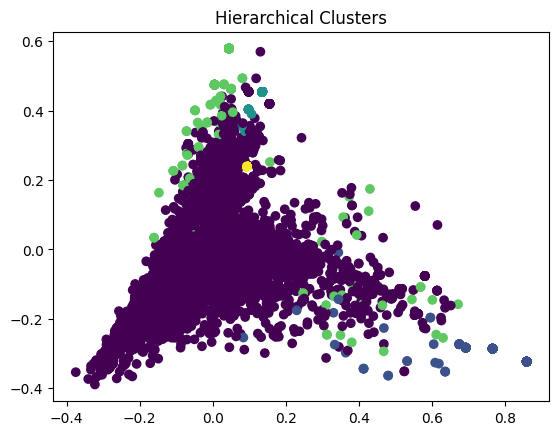

In [56]:
#Hierarchical Visualization
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['hier_cluster'])
plt.title("Hierarchical Clusters")
plt.show()

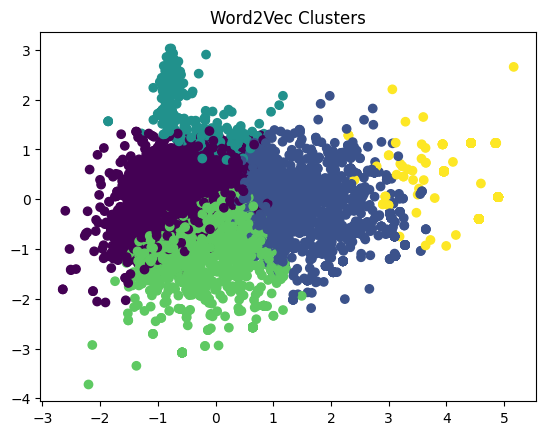

In [57]:
#Word2Vec Visualization
X_w2v_pca = PCA(n_components=2).fit_transform(X_w2v)

plt.scatter(X_w2v_pca[:,0], X_w2v_pca[:,1], c=df['w2v_cluster'])
plt.title("Word2Vec Clusters")
plt.show()

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**The clustering results showed noticeable differences across the applied methods. K-means produced relatively well-defined and balanced clusters, but it relied heavily on the assumption of spherical cluster shapes and required predefining the number of clusters. DBSCAN, on the other hand, was effective in identifying dense regions and filtering out noise, but its performance was sensitive to parameter selection, often resulting in many points being labeled as outliers. Hierarchical clustering provided a more structured grouping and allowed visualization through a dendrogram, but it was computationally expensive for larger datasets. Word2Vec-based clustering demonstrated improved semantic grouping compared to TF-IDF-based approaches, as it captured contextual relationships between words, leading to more meaningful clusters. If applied, BERT-based clustering would further enhance semantic understanding by leveraging deep contextual embeddings, typically producing the most coherent clusters, although at the cost of higher computational complexity. Overall, embedding-based methods (Word2Vec/BERT) tend to outperform traditional approaches in capturing the true meaning of text data.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

